In [ ]:
import numpy as np
import os
import cv2
from PIL import Image
import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
image_directory = '/content/drive/My Drive/cell_images/'

In [ ]:
SIZE = 64
dataset = []
label = []

In [ ]:
parasitized_images = os.listdir(image_directory + 'parasitized/')
for i, image_name in enumerate(parasitized_images):
    if image_name.endswith('.png'):
        image = cv2.imread(image_directory + 'parasitized/' + image_name)
        image = Image.fromarray(image, 'RGB')
        image = image.resize((SIZE, SIZE))
        dataset.append(np.array(image))
        label.append(0)

In [ ]:
uninfected_images = os.listdir(image_directory + 'uninfected/')
for i, image_name in enumerate(uninfected_images):
    if image_name.endswith('.png'):
        image = cv2.imread(image_directory + 'uninfected/' + image_name)
        image = Image.fromarray(image, 'RGB')
        image = image.resize((SIZE, SIZE))
        dataset.append(np.array(image))
        label.append(1)

/tmp/ipykernel_841/3698679363.py:5: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image, 'RGB')


In [ ]:
INPUT_SHAPE = (SIZE, SIZE, 3)
inp = keras.layers.Input(shape=INPUT_SHAPE)
#layer1
conv1 = keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same')(inp)
pool1 = keras.layers.MaxPooling2D(pool_size=(2, 2))(conv1)
norm1 = keras.layers.BatchNormalization()(pool1)
drop1 = keras.layers.Dropout(rate=0.2)(norm1)
#layer2
conv2 = keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same')(drop1)  # Increased filters
pool2 = keras.layers.MaxPooling2D(pool_size=(2, 2))(conv2)
norm2 = keras.layers.BatchNormalization()(pool2)
drop2 = keras.layers.Dropout(rate=0.2)(norm2)

flat = keras.layers.Flatten()(drop2)
hidden1 = keras.layers.Dense(512, activation='relu')(flat)
norm3 = keras.layers.BatchNormalization()(hidden1)
drop3 = keras.layers.Dropout(rate=0.2)(norm3)
hidden2 = keras.layers.Dense(256, activation='relu')(drop3)
norm4 = keras.layers.BatchNormalization()(hidden2)
drop4 = keras.layers.Dropout(rate=0.2)(norm4)

out = keras.layers.Dense(2, activation='softmax')(drop4)  # Change to softmax for categorical classification

model = keras.Model(inputs=inp, outputs=out)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,543,810 (32.59 MB)

 Trainable params: 8,542,082 (32.59 MB)

 Non-trainable params: 1,728 (6.75 KB)

None


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(dataset, to_categorical(np.array(label)), test_size=0.20, random_state=0)

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
datagen.fit(X_train)

In [ ]:
history = model.fit(np.array(X_train),
                    y_train,
                    batch_size=64,
                    verbose=1,
                    epochs=50,  # Set to 5 for testing; you can change this as needed
                    validation_split=0.1,
                    shuffle=False)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.7143 - loss: 0.7582 - val_accuracy: 0.0000e+00 - val_loss: 20.6503
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.2857 - loss: 1.3663 - val_accuracy: 0.0000e+00 - val_loss: 12.9121
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.4286 - loss: 1.0398 - val_accuracy: 0.0000e+00 - val_loss: 15.9375
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.4286 - loss: 0.8818 - val_accuracy: 0.0000e+00 - val_loss: 16.9718
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5714 - loss: 0.7781 - val_accuracy: 0.0000e+00 - val_loss: 14.5386
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.6429 - loss: 0.8478 - val_accuracy: 0.0000e+00 - val_loss: 10.7102
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.4286 - loss: 0.8890 - val_accuracy: 0.0000e+00 - val_loss: 7.8037
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.2857 - loss: 0.8814 - val_ac

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 687ms/step - accuracy: 0.0000e+00 - loss: 3.7932


Test Accuracy: 0.00%


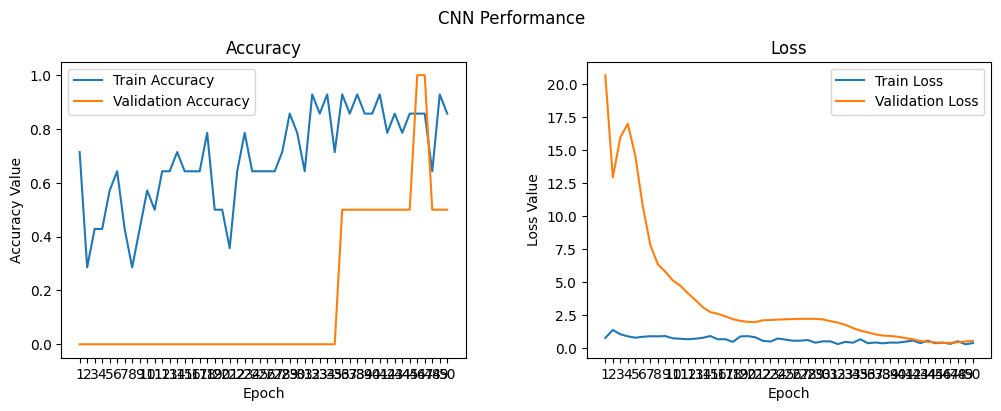

In [ ]:
# Calculate accuracy on the test data
print("Test Accuracy: {:.2f}%".format(model.evaluate(np.array(X_test), np.array(y_test))[1] * 100))

# Plot training history
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
t = f.suptitle('CNN Performance', fontsize=12)
f.subplots_adjust(top=0.85, wspace=0.3)
max_epoch = len(history.history['accuracy']) + 1
epoch_list = list(range(1, max_epoch))
ax1.plot(epoch_list, history.history['accuracy'], label='Train Accuracy')
ax1.plot(epoch_list, history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_xticks(np.arange(1, max_epoch, 1))
ax1.set_ylabel('Accuracy Value')
ax1.set_xlabel('Epoch')
ax1.set_title('Accuracy')
l1 = ax1.legend(loc="best")

ax2.plot(epoch_list, history.history['loss'], label='Train Loss')
ax2.plot(epoch_list, history.history['val_loss'], label='Validation Loss')
ax2.set_xticks(np.arange(1, max_epoch, 1))
ax2.set_ylabel('Loss Value')
ax2.set_xlabel('Epoch')
ax2.set_title('Loss')
l2 = ax2.legend(loc="best")

# Save the model
model.save('/content/drive/My Drive/malaria_cnn.h5')

In [ ]:
#Loading data from computer
from google.colab import files
from PIL import Image
import numpy as np
import cv2

# Upload an image
uploaded = files.upload()

Saving C1_thinF_IMG_20150604_104722_cell_15.png to C1_thinF_IMG_20150604_104722_cell_15.png


In [ ]:
# Load the uploaded image
for filename in uploaded.keys():
    # Open the image
    img = Image.open(filename)

    # Resize the image to (64, 64)
    img = img.resize((64, 64))

    # Convert the image to a numpy array and scale to [0, 1]
    img_array = np.array(img) / 255.0

    # Expand dimensions to match the input shape of the model
    img_array = np.expand_dims(img_array, axis=0)  # Shape: (1, 64, 64, 3)

In [ ]:
from keras.models import load_model
model = load_model('/content/drive/My Drive/malaria_cnn.h5')  # Ensure you have saved the model earlier

# Make prediction
prediction = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 554ms/step


In [ ]:
class_label = np.argmax(prediction, axis=1)
print(class_label)

if class_label[0] == 0:
    print("The image is of a parasitized cell.")
else:
    print("The image is of an uninfected cell.")

[0]
The image is of a parasitized cell.
